In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn
%pip install catboost lightgbm xgboost
%pip install optuna
%pip install jupyter
%pip install nltk
%pip install wordcloud
%pip install tqdm
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   -- ------------------------------------- 6.6/100.2 MB 34.7 MB/s eta 0:00:03
   ---- ----------------------------------- 11.5/100.2 MB 29.9 MB/s eta 0:00:03
   ----- ---------------------------------- 12.8/100.2 MB 21.6 MB/s eta 0:00:05
   ----- ---------------------------------- 13.9/100.2 MB 16.9 MB/s eta 0:00:06
   ------ --------------------------------- 15.2/100.2 MB 14.8 MB/s eta 0:00:06
   ------ --------------------------------- 17.3/100.2 MB 13.8 MB/s eta 0:00:07
   ------- -------------------------------- 19.9/100.2 MB 13.6 MB/s eta 0:00:06
   -------- ------------------------------- 22.5/100.2 MB 13.5 MB/s eta 0:00:06
   ---------- ----------------------------- 25.4/100.2 MB 13.4 MB/s eta 0:00:06
   ----------- ---------------------------- 28.8/100.2 MB 13.7 MB/s eta 0:00:06
   ------------ --------------------------- 32.0/100.2 MB 13.8 M

In [55]:
##data_audit


In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

attendance = pd.read_csv("../data/raw/Attendance_series.csv")

notes = pd.read_csv("../data/raw/Counsellor_notes.csv")

dictionary = pd.read_csv("../data/raw/Data_dictionary.csv")

In [3]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Attendance:", attendance.shape)
print("Notes:", notes.shape)

Train: (12000, 18)
Test: (3000, 17)
Attendance: (1048575, 5)
Notes: (15000, 2)


In [4]:
train.columns

Index(['student_id', 'branch', 'gender', 'hostel_status', 'family_income',
       'parent_education', 'scholarship', 'part_time_job', 'commute_time_mins',
       'screen_time_hours', 'cgpa_sem1', 'cgpa_sem2', 'cgpa_sem3', 'cgpa_sem4',
       'backlogs_sem1', 'backlogs_sem2', 'backlogs_sem3', 'dropout_risk'],
      dtype='object')

In [5]:
train["dropout_risk"].value_counts(normalize=True)

dropout_risk
0    0.60
1    0.25
2    0.15
Name: proportion, dtype: float64

<Axes: xlabel='dropout_risk'>

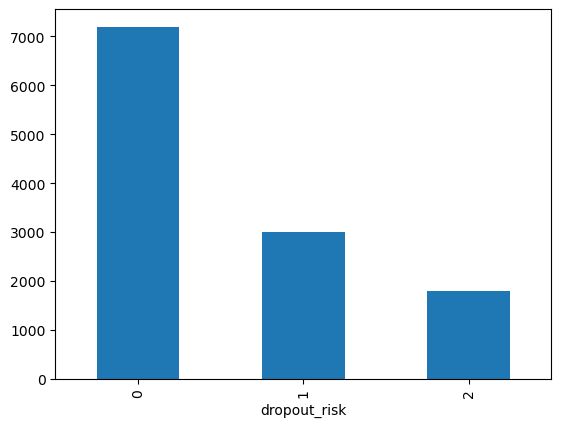

In [6]:
train["dropout_risk"].value_counts().plot.bar()

In [7]:
missing = train.isnull().sum()

missing[missing > 0]

parent_education     238
commute_time_mins    387
dtype: int64

In [8]:
(train.isnull().mean()*100).sort_values(ascending=False)

commute_time_mins    3.225000
parent_education     1.983333
branch               0.000000
student_id           0.000000
hostel_status        0.000000
gender               0.000000
family_income        0.000000
scholarship          0.000000
part_time_job        0.000000
screen_time_hours    0.000000
cgpa_sem1            0.000000
cgpa_sem2            0.000000
cgpa_sem3            0.000000
cgpa_sem4            0.000000
backlogs_sem1        0.000000
backlogs_sem2        0.000000
backlogs_sem3        0.000000
dropout_risk         0.000000
dtype: float64

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         12000 non-null  object 
 1   branch             12000 non-null  object 
 2   gender             12000 non-null  object 
 3   hostel_status      12000 non-null  object 
 4   family_income      12000 non-null  object 
 5   parent_education   11762 non-null  object 
 6   scholarship        12000 non-null  int64  
 7   part_time_job      12000 non-null  int64  
 8   commute_time_mins  11613 non-null  float64
 9   screen_time_hours  12000 non-null  float64
 10  cgpa_sem1          12000 non-null  float64
 11  cgpa_sem2          12000 non-null  float64
 12  cgpa_sem3          12000 non-null  float64
 13  cgpa_sem4          12000 non-null  float64
 14  backlogs_sem1      12000 non-null  int64  
 15  backlogs_sem2      12000 non-null  int64  
 16  backlogs_sem3      120

In [10]:
train.select_dtypes(include=np.number).columns

Index(['scholarship', 'part_time_job', 'commute_time_mins',
       'screen_time_hours', 'cgpa_sem1', 'cgpa_sem2', 'cgpa_sem3', 'cgpa_sem4',
       'backlogs_sem1', 'backlogs_sem2', 'backlogs_sem3', 'dropout_risk'],
      dtype='object')

In [11]:
train.select_dtypes(include="object").columns

Index(['student_id', 'branch', 'gender', 'hostel_status', 'family_income',
       'parent_education'],
      dtype='object')

In [12]:
train.duplicated().sum()



np.int64(0)

In [13]:
test.duplicated().sum()

np.int64(0)

In [14]:
train["student_id"].nunique()



12000

In [15]:
test["student_id"].nunique()

3000

In [16]:
attendance.head()

,student_id,semester,week,subject,attendance_pct
0,STU00001,1,1,Core_1,1.0000
1,STU00002,1,1,Core_1,0.9198
2,STU00003,1,1,Core_1,0.8364
3,STU00004,1,1,Core_1,0.9640
4,STU00005,1,1,Core_1,0.7429


In [17]:
attendance.columns

Index(['student_id', 'semester', 'week', 'subject', 'attendance_pct'], dtype='object')

In [18]:
attendance.groupby("student_id").size().describe()

count    15000.000000
mean        69.905000
std          0.293225
min         69.000000
25%         70.000000
50%         70.000000
75%         70.000000
max         70.000000
dtype: float64

In [19]:
notes.head()

,student_id,counsellor_note
0,STU00001,Student is performing well. Follow-up required.
1,STU00002,Needs to improve focus in class. Action plan d...
2,STU00003,"Struggling slightly with core subjects, advise..."
3,STU00004,Student expressed some stress regarding course...
4,STU00005,Multiple backlogs. Demotivated. Action plan di...


In [20]:
notes.columns

Index(['student_id', 'counsellor_note'], dtype='object')

In [21]:
notes["counsellor_note"].str.len().describe()


count    15000.000000
mean        55.766133
std         10.107145
min         45.000000
25%         48.000000
50%         52.000000
75%         62.000000
max         80.000000
Name: counsellor_note, dtype: float64

In [22]:
print(notes.columns)

Index(['student_id', 'counsellor_note'], dtype='object')


In [23]:
#02_baseline

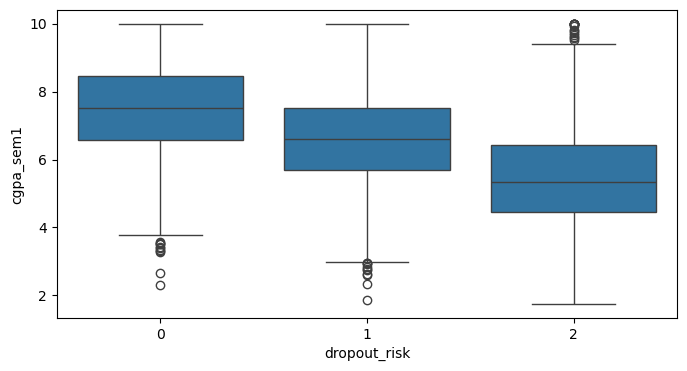

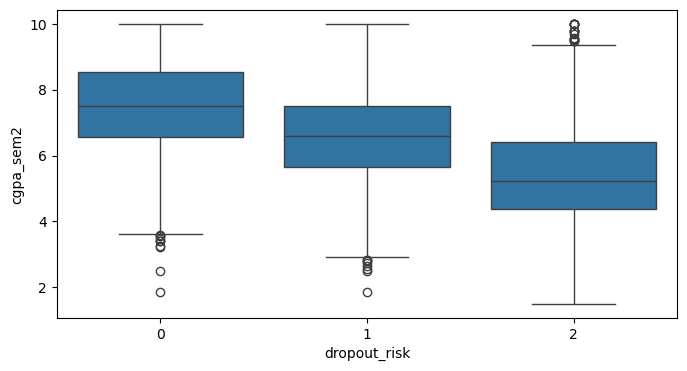

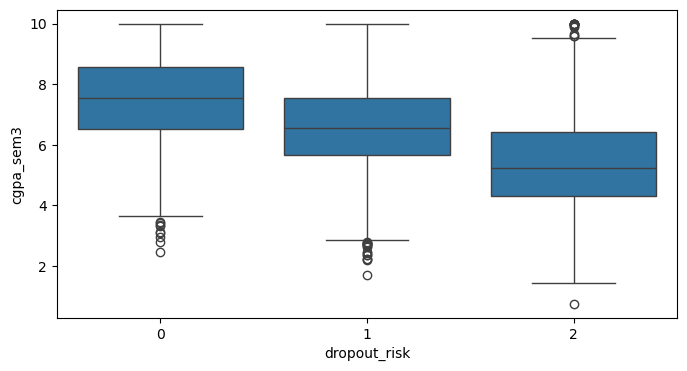

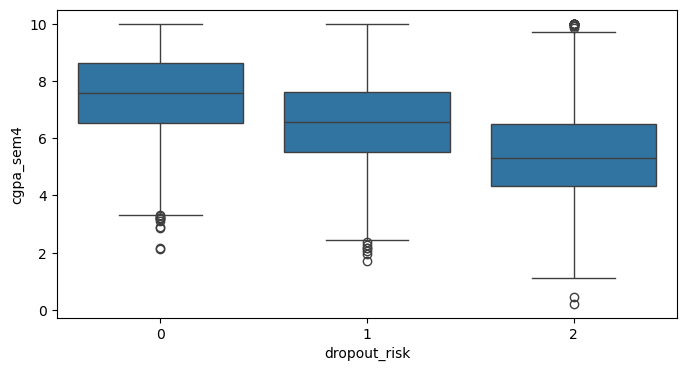

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cgpa_cols = [
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4"
]

for col in cgpa_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x="dropout_risk",
        y=col,
        data=train
    )
    plt.show()

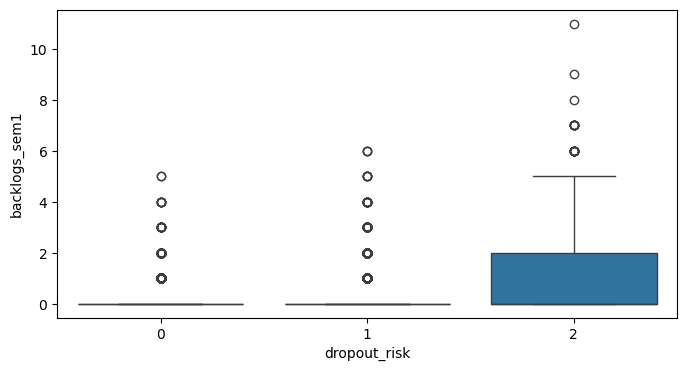

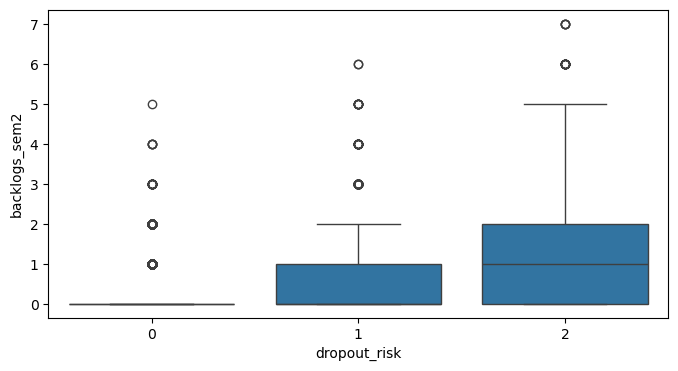

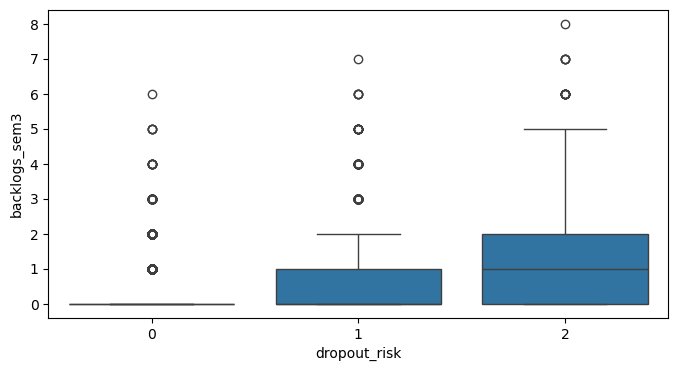

In [25]:
backlog_cols = [
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3"
]

for col in backlog_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x="dropout_risk",
        y=col,
        data=train
    )
    plt.show()

<Axes: xlabel='dropout_risk', ylabel='screen_time_hours'>

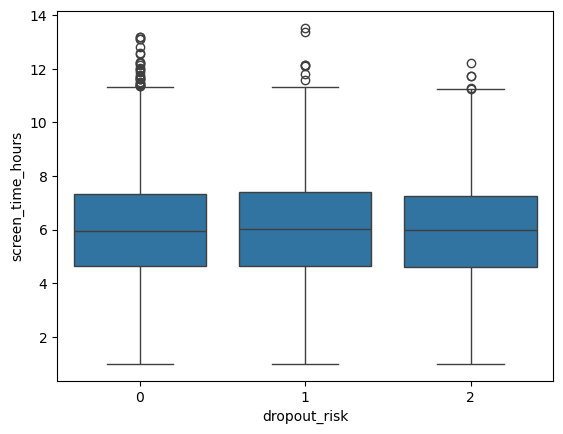

In [26]:
sns.boxplot(
    x="dropout_risk",
    y="screen_time_hours",
    data=train
)

In [27]:
cat_cols = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education"
]

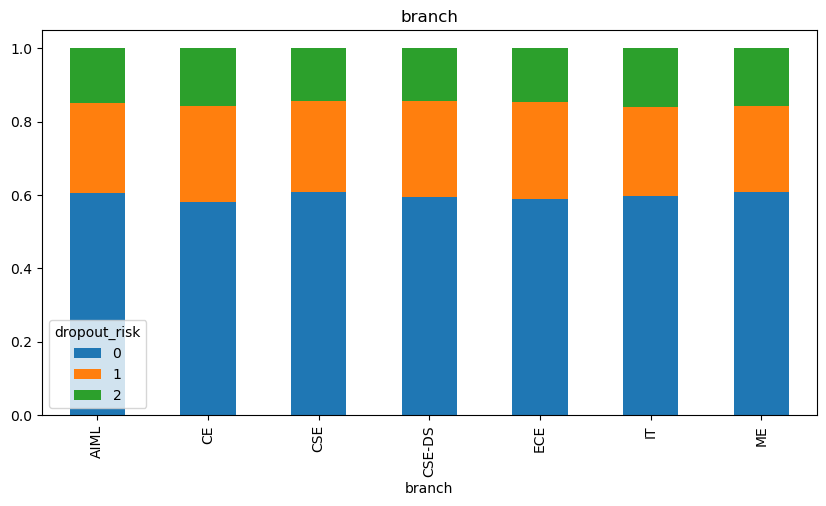

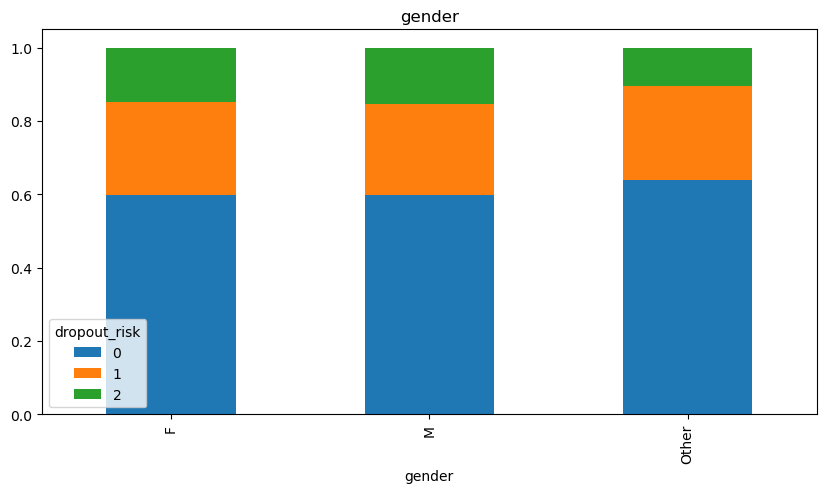

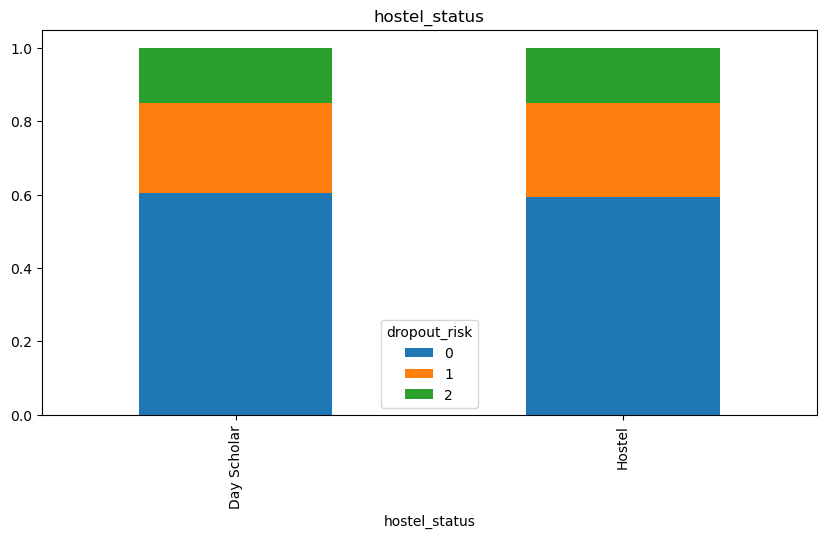

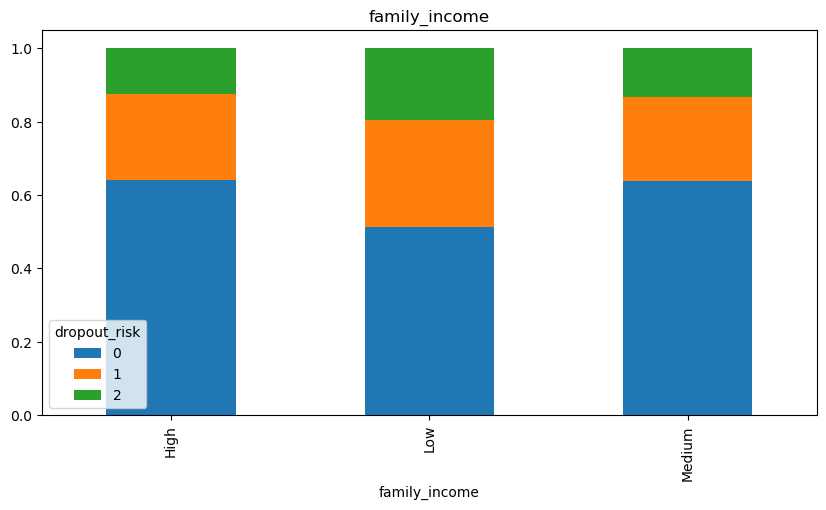

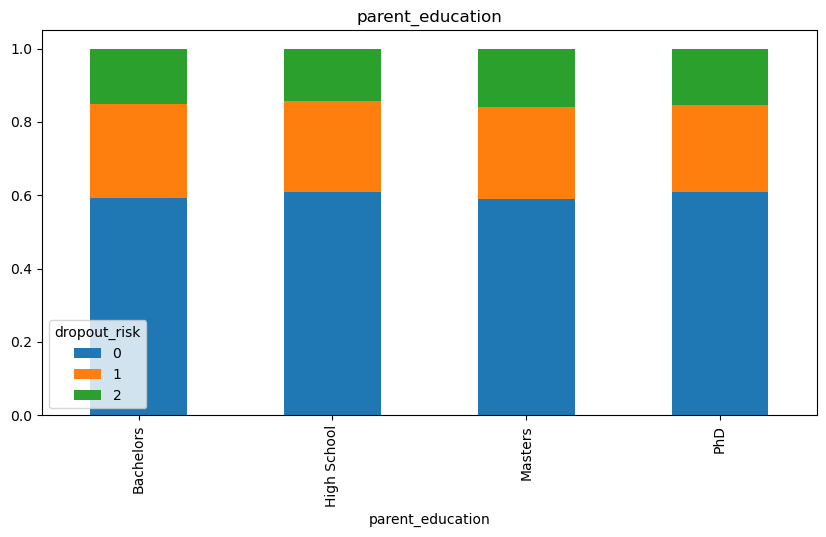

In [28]:
for col in cat_cols:

    temp = pd.crosstab(
        train[col],
        train["dropout_risk"],
        normalize="index"
    )

    temp.plot(
        kind="bar",
        stacked=True,
        figsize=(10,5)
    )

    plt.title(col)
    plt.show()

<Axes: >

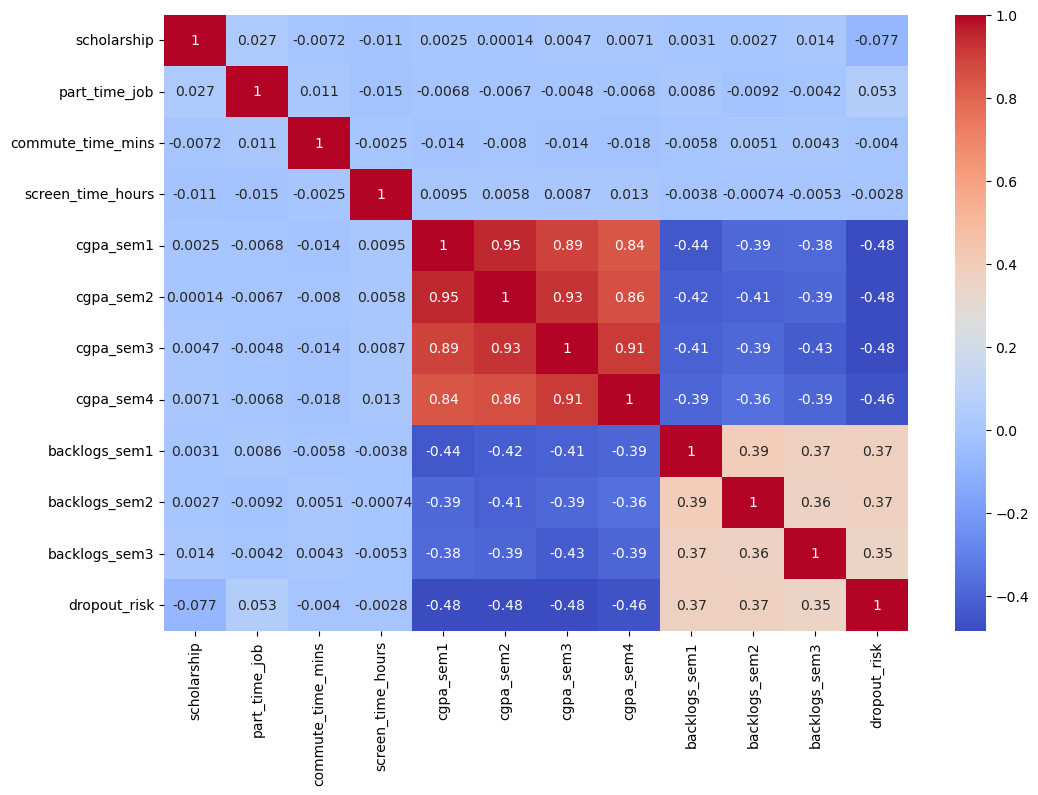

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

In [30]:
attendance_mean = (
    attendance.groupby("student_id")["attendance_pct"]
    .mean()
    .reset_index()
)

attendance_mean.head()



,student_id,attendance_pct
0,STU00001,0.806669
1,STU00002,0.913447
2,STU00003,0.743041
3,STU00004,0.781174
4,STU00005,0.782371


In [31]:
attendance_mean.rename(
    columns={"attendance_pct": "attendance_mean"},
    inplace=True
)

In [32]:
merged_df = train.merge(
    attendance_mean,
    on="student_id",
    how="left"
)

merged_df.head()

,student_id,branch,gender,hostel_status,family_income,parent_education,scholarship,part_time_job,commute_time_mins,screen_time_hours,cgpa_sem1,cgpa_sem2,cgpa_sem3,cgpa_sem4,backlogs_sem1,backlogs_sem2,backlogs_sem3,dropout_risk,attendance_mean
0,STU03539,AIML,M,Hostel,High,Bachelors,1,0,NaN,3.256760,7.20,7.50,7.54,7.89,0,0,0,0,0.811020
1,STU12726,CE,M,Hostel,Medium,Masters,0,0,67.0,5.088147,5.12,5.02,4.82,5.14,1,0,3,1,0.697454
2,STU01218,AIML,F,Day Scholar,Low,High School,1,0,NaN,5.559880,7.92,8.86,9.26,9.00,0,1,0,0,0.851791
3,STU01949,CSE-DS,M,Hostel,Medium,High School,1,0,27.0,5.675544,7.00,6.91,6.75,7.06,0,1,0,0,0.821037
4,STU01594,CSE,M,Day Scholar,Medium,PhD,1,0,53.0,4.844319,6.48,6.99,7.61,6.36,0,0,0,0,0.784809


In [33]:
print(merged_df.shape)

merged_df[["student_id", "attendance_mean"]].head()

(12000, 19)


,student_id,attendance_mean
0,STU03539,0.811020
1,STU12726,0.697454
2,STU01218,0.851791
3,STU01949,0.821037
4,STU01594,0.784809


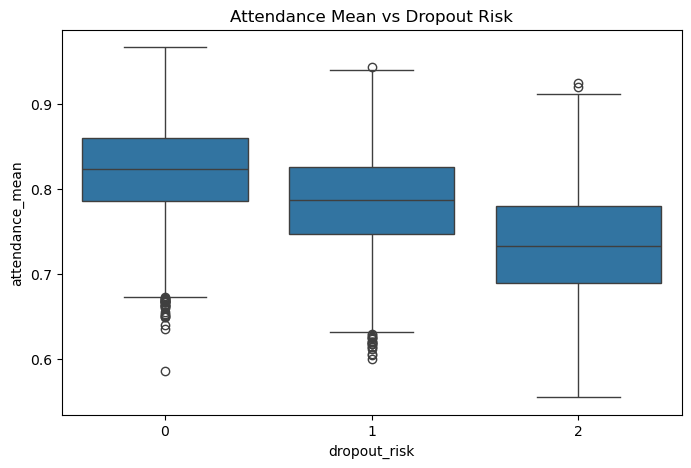

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="dropout_risk",
    y="attendance_mean",
    data=merged_df
)

plt.title("Attendance Mean vs Dropout Risk")
plt.show()

In [35]:
attendance_features = (
    attendance.groupby("student_id")["attendance_pct"]
    .agg(
        attendance_mean="mean",
        attendance_std="std",
        attendance_min="min",
        attendance_max="max"
    )
    .reset_index()
)

attendance_features["attendance_range"] = (
    attendance_features["attendance_max"]
    - attendance_features["attendance_min"]
)

attendance_features.head()

,student_id,attendance_mean,attendance_std,attendance_min,attendance_max,attendance_range
0,STU00001,0.806669,0.214452,0.1276,1.0,0.8724
1,STU00002,0.913447,0.175171,0.1816,1.0,0.8184
2,STU00003,0.743041,0.209314,0.1237,1.0,0.8763
3,STU00004,0.781174,0.191048,0.1394,1.0,0.8606
4,STU00005,0.782371,0.183122,0.1460,1.0,0.8540


In [36]:
merged_df = train.merge(
    attendance_features,
    on="student_id",
    how="left"
)

In [37]:
merged_df.groupby("dropout_risk")[
    ["attendance_mean",
     "attendance_std",
     "attendance_min",
     "attendance_max"]
].mean()

,attendance_mean,attendance_std,attendance_min,attendance_max
dropout_risk,,,,
0,0.820955,0.189251,0.159751,0.999931
1,0.784389,0.190448,0.149056,0.999489
2,0.735404,0.189883,0.135765,0.997240


In [38]:
train.groupby("dropout_risk")[
    ["cgpa_sem1","cgpa_sem2","cgpa_sem3","cgpa_sem4"]
].mean()

,cgpa_sem1,cgpa_sem2,cgpa_sem3,cgpa_sem4
dropout_risk,,,,
0,7.518154,7.533569,7.535549,7.528779
1,6.617840,6.599487,6.588023,6.567347
2,5.485328,5.443139,5.393733,5.401867


In [39]:
# Save to a fast binary file
merged_df.to_feather("Data/raw/merged_df.feather")

OSError: Cannot save file into a non-existent directory: 'Data\raw'

In [57]:
#03_baseline_catboost

In [40]:
train["cgpa_mean"] = train[
    ["cgpa_sem1","cgpa_sem2","cgpa_sem3","cgpa_sem4"]
].mean(axis=1)

train["cgpa_std"] = train[
    ["cgpa_sem1","cgpa_sem2","cgpa_sem3","cgpa_sem4"]
].std(axis=1)

train["cgpa_trend"] = (
    train["cgpa_sem4"]
    - train["cgpa_sem1"]
)

In [41]:
train["backlog_total"] = train[
    ["backlogs_sem1","backlogs_sem2","backlogs_sem3"]
].sum(axis=1)

train["backlog_mean"] = train[
    ["backlogs_sem1","backlogs_sem2","backlogs_sem3"]
].mean(axis=1)

train["backlog_trend"] = (
    train["backlogs_sem3"]
    - train["backlogs_sem1"]
)

In [42]:
attendance_mean


,student_id,attendance_mean
0,STU00001,0.806669
1,STU00002,0.913447
2,STU00003,0.743041
3,STU00004,0.781174
4,STU00005,0.782371
...,...,...
14995,STU14996,0.643422
14996,STU14997,0.745248
14997,STU14998,0.676088
14998,STU14999,0.838183


In [43]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [44]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# 1. Separate features and target
X = train.drop(columns=["dropout_risk", "student_id"])
y = train["dropout_risk"]

# 2. Identify and prepare categorical columns
categorical_cols = ["branch", "gender", "hostel_status", "family_income", "parent_education"]

for col in categorical_cols:
    # Fill any missing values and ensure they are strings
    X[col] = X[col].fillna("Missing").astype(str)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize CatBoostClassifier WITH cat_features specified
model = CatBoostClassifier(
    random_seed=42, 
    verbose=100, 
    cat_features=categorical_cols
)

# 5. Fit the model
model.fit(X_train, y_train)

Learning rate set to 0.088801
0:	learn: 1.0479334	total: 229ms	remaining: 3m 49s
100:	learn: 0.7314598	total: 8.7s	remaining: 1m 17s
200:	learn: 0.6931474	total: 17.5s	remaining: 1m 9s
300:	learn: 0.6590880	total: 26.3s	remaining: 1m 1s
400:	learn: 0.6271715	total: 35.5s	remaining: 53s
500:	learn: 0.5983133	total: 45s	remaining: 44.8s
600:	learn: 0.5717917	total: 53.7s	remaining: 35.6s
700:	learn: 0.5441261	total: 1m 3s	remaining: 26.9s
800:	learn: 0.5171755	total: 1m 12s	remaining: 18s
900:	learn: 0.4932699	total: 1m 21s	remaining: 8.93s
999:	learn: 0.4703201	total: 1m 30s	remaining: 0us


CatBoostClassifier(cat_features=['branch', 'gender', 'hostel_status', 'family_income', 'parent_education'], random_seed=42, verbose=100)

In [45]:
# Predict on X_test (your validation set)
y_pred = model.predict(X_test).flatten()

# Evaluate the score
from sklearn.metrics import f1_score
score = f1_score(y_test, y_pred, average="macro")
print(f"Validation Macro F1-Score: {score:.4f}")

Validation Macro F1-Score: 0.4975


In [46]:
from sklearn.metrics import f1_score

score = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(score)

0.49748980094926337


In [47]:
print(notes["counsellor_note"].nunique())

notes["counsellor_note"].value_counts().head(20)

54


counsellor_note
Good academic-social balance. Action plan discussed.                        471
Good academic-social balance. Follow-up required.                           459
Participates actively in class. Situation monitored.                        456
Participates actively in class. Follow-up required.                         452
Participates actively in class. Action plan discussed.                      451
No further action needed. Action plan discussed.                            451
No further action needed. Situation monitored.                              450
No major issues reported. Situation monitored.                              447
No major issues reported. Action plan discussed.                            447
Discussed minor career goals, doing fine. Action plan discussed.            443
Good academic-social balance. Situation monitored.                          442
Student is performing well. Situation monitored.                            441
No further action needed

In [48]:
X.columns.tolist()

['branch',
 'gender',
 'hostel_status',
 'family_income',
 'parent_education',
 'scholarship',
 'part_time_job',
 'commute_time_mins',
 'screen_time_hours',
 'cgpa_sem1',
 'cgpa_sem2',
 'cgpa_sem3',
 'cgpa_sem4',
 'backlogs_sem1',
 'backlogs_sem2',
 'backlogs_sem3',
 'cgpa_mean',
 'cgpa_std',
 'cgpa_trend',
 'backlog_total',
 'backlog_mean',
 'backlog_trend']

In [49]:
print(X.shape)

(12000, 22)


In [50]:
y_pred[:20]

array([0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0])

In [51]:
y_test[:20]

362      0
11908    2
3391     1
3739     0
10878    1
10660    0
9845     0
11297    2
7143     0
8305     0
8166     0
1153     0
3876     1
10577    0
293      2
9530     0
9298     0
7223     0
9762     0
9319     1
Name: dropout_risk, dtype: int64

In [52]:
from collections import Counter

print(Counter(y_pred))
print(Counter(y_test))

Counter({np.int64(0): 1841, np.int64(1): 307, np.int64(2): 252})
Counter({0: 1440, 1: 600, 2: 360})


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.89      0.78      1440
           1       0.32      0.16      0.22       600
           2       0.60      0.42      0.50       360

    accuracy                           0.64      2400
   macro avg       0.54      0.49      0.50      2400
weighted avg       0.59      0.64      0.60      2400



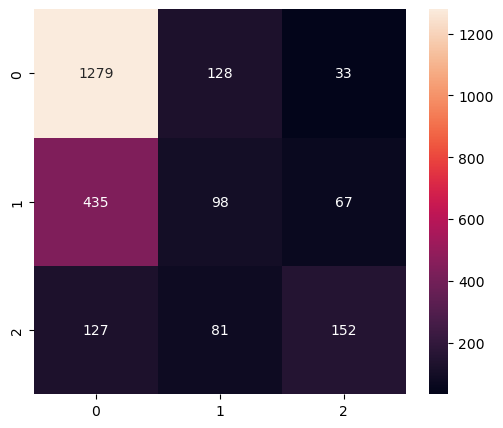

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [55]:
cat_features = ["branch", "gender", "hostel_status", "family_income", "parent_education"]

for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)

In [56]:
attendance_features = (
    attendance.groupby("student_id")["attendance_pct"]
    .agg(
        attendance_mean="mean",
        attendance_std="std",
        attendance_min="min",
        attendance_max="max"
    )
    .reset_index()
)

attendance_features["attendance_range"] = (
    attendance_features["attendance_max"]
    - attendance_features["attendance_min"]
)

In [57]:
train = train.merge(
    attendance_features,
    on="student_id",
    how="left"
)

In [58]:
test = test.merge(
    attendance_features,
    on="student_id",
    how="left"
)

In [59]:
print(train.shape)
print(test.shape)

(12000, 29)
(3000, 22)


In [60]:
train[
    [
        "attendance_mean",
        "attendance_std",
        "attendance_min",
        "attendance_max",
        "attendance_range"
    ]
].isnull().sum()

attendance_mean     0
attendance_std      0
attendance_min      0
attendance_max      0
attendance_range    0
dtype: int64

In [63]:
features += [
    'attendance_mean',
    'attendance_std',
    'attendance_min',
    'attendance_max',
    'attendance_range'
]

In [62]:
features = [
 'branch',
 'gender',
 'hostel_status',
 'family_income',
 'parent_education',
 'scholarship',
 'part_time_job',
 'commute_time_mins',
 'screen_time_hours',
 'cgpa_sem1',
 'cgpa_sem2',
 'cgpa_sem3',
 'cgpa_sem4',
 'backlogs_sem1',
 'backlogs_sem2',
 'backlogs_sem3',
 'cgpa_mean',
 'cgpa_std',
 'cgpa_trend',
 'backlog_total',
 'backlog_mean',
 'backlog_trend'
]

In [64]:
X = train[features]

y = train["dropout_risk"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [66]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)

In [67]:
# 1. Force a copy to avoid SettingWithCopy issues
X_train = X_train.copy()

cat_features = ["branch", "gender", "hostel_status", "family_income", "parent_education"]

# 2. Fill NaNs and cast to string
for col in cat_features:
    X_train[col] = X_train[col].fillna("Missing").astype(str)

# 3. Double-check there are absolutely no NaNs left in these columns
print("NaN count check:")
print(X_train[cat_features].isna().sum())

# 4. Now run the fit command
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

NaN count check:
branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64
0:	learn: 0.5927162	total: 85.2ms	remaining: 2m 7s
100:	learn: 0.6172379	total: 12.3s	remaining: 2m 50s
200:	learn: 0.6447339	total: 25.8s	remaining: 2m 46s
300:	learn: 0.6652917	total: 39.8s	remaining: 2m 38s
400:	learn: 0.6878857	total: 53.9s	remaining: 2m 27s
500:	learn: 0.7123888	total: 1m 7s	remaining: 2m 14s
600:	learn: 0.7331051	total: 1m 21s	remaining: 2m 1s
700:	learn: 0.7565861	total: 1m 35s	remaining: 1m 48s
800:	learn: 0.7750325	total: 1m 49s	remaining: 1m 35s
900:	learn: 0.7922879	total: 2m 3s	remaining: 1m 22s
1000:	learn: 0.8102843	total: 2m 18s	remaining: 1m 9s
1100:	learn: 0.8260129	total: 2m 33s	remaining: 55.7s
1200:	learn: 0.8442016	total: 2m 47s	remaining: 41.8s
1300:	learn: 0.8599646	total: 3m 2s	remaining: 27.9s
1400:	learn: 0.8741822	total: 3m 17s	remaining: 14s
1499:	learn: 0.8873297	total: 3m 31s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='TotalF1', iterations=1500, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=100)

In [68]:
from sklearn.metrics import f1_score

# 1. Clean X_valid to prevent NaN errors during prediction
X_valid = X_valid.copy()
cat_features = ["branch", "gender", "hostel_status", "family_income", "parent_education"]
for col in cat_features:
    X_valid[col] = X_valid[col].fillna("Missing").astype(str)

# 2. Make predictions and flatten to a 1D array
preds = model.predict(X_valid).flatten()

# 3. Calculate and print Macro F1 score
score = f1_score(
    y_valid,
    preds,
    average="macro"
)

print(f"Validation Macro F1-Score: {score:.4f}")

Validation Macro F1-Score: 0.4996


In [69]:
importance = model.get_feature_importance(prettified=True)

importance.head(20)

,Feature Id,Importances
0,screen_time_hours,7.256660
1,attendance_std,6.861369
2,commute_time_mins,6.824924
3,family_income,6.587983
4,parent_education,6.353501
5,cgpa_std,6.278123
6,branch,5.926479
7,attendance_mean,5.748703
8,gender,5.454280
9,cgpa_trend,5.224989


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# 1. Create the attendance features DataFrame
attendance_stats = attendance.groupby("student_id")["attendance_pct"].agg(
    attendance_mean="mean",
    attendance_std="std",
    attendance_min="min",
    attendance_max="max"
).reset_index()

# Calculate the attendance range (max - min)
attendance_stats["attendance_range"] = attendance_stats["attendance_max"] - attendance_stats["attendance_min"]

# 2. Merge it into the main train DataFrame
train_merged = train.merge(attendance_stats, on="student_id", how="left")

# 3. Separate features (X) and target (y)
X = train_merged.drop(columns=["dropout_risk", "student_id"])
y = train_merged["dropout_risk"]

# 4. Clean categorical columns in X
cat_features = ["branch", "gender", "hostel_status", "family_income", "parent_education"]
for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)

# 5. Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Initialize and train the model
model = CatBoostClassifier(
    random_seed=42, 
    verbose=100, 
    cat_features=cat_features
)
model.fit(X_train, y_train)

# 7. Make predictions on X_test
preds = model.predict(X_test).flatten()

Learning rate set to 0.088801
0:	learn: 1.0475789	total: 79.6ms	remaining: 1m 19s
100:	learn: 0.7262742	total: 9.34s	remaining: 1m 23s
200:	learn: 0.6845764	total: 19.1s	remaining: 1m 15s
300:	learn: 0.6480378	total: 28.6s	remaining: 1m 6s
400:	learn: 0.6129082	total: 38.2s	remaining: 57s
500:	learn: 0.5786567	total: 48s	remaining: 47.8s
600:	learn: 0.5460658	total: 58.1s	remaining: 38.6s
700:	learn: 0.5184961	total: 1m 7s	remaining: 29s
800:	learn: 0.4925623	total: 1m 18s	remaining: 19.5s
900:	learn: 0.4684953	total: 1m 28s	remaining: 9.71s
999:	learn: 0.4459544	total: 1m 38s	remaining: 0us


In [71]:

preds = model.predict(X_test).flatten()

In [72]:
print(preds.shape)
print(type(preds))

(2400,)
<class 'numpy.ndarray'>


In [73]:
train.groupby("dropout_risk")[
    ["cgpa_mean", "backlog_total"]
].mean()

,cgpa_mean,backlog_total
dropout_risk,,
0,7.529013,0.530000
1,6.593174,1.117333
2,5.431017,3.345000


In [74]:
features = [
    'branch',
    'gender',
    'hostel_status',
    'family_income',
    'parent_education',
    'scholarship',
    'part_time_job',
    'commute_time_mins',
    'screen_time_hours',
    'cgpa_sem1',
    'cgpa_sem2',
    'cgpa_sem3',
    'cgpa_sem4',
    'backlogs_sem1',
    'backlogs_sem2',
    'backlogs_sem3'
]

In [75]:
# 1. Define X and y from train_merged
X = train_merged.drop(columns=["dropout_risk", "student_id"])
y = train_merged["dropout_risk"]

# 2. Clean the master X DataFrame immediately (BEFORE the loop starts)
cat_features = ["branch", "gender", "hostel_status", "family_income", "parent_education"]
for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)

# 3. Your cross-validation setup (e.g., StratifiedKFold)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. The loop
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]
    
    # Initialize model
    model = CatBoostClassifier(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=False  # Keep loop output clean
    )
    
    # This will now succeed without any NaN errors!
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )
    
    # Make predictions
    preds = model.predict(X_valid).flatten()
    

In [76]:
from sklearn.metrics import f1_score

# 1. Make predictions and flatten (X_test is already cleaned from step 2 of the loop)
preds = model.predict(X_test).flatten()

# 2. Calculate and print the Macro F1 score for the final fold
score = f1_score(
    y_test,
    preds,
    average="macro"
)

print(f"Final Fold Validation Macro F1-Score: {score:.4f}")

Final Fold Validation Macro F1-Score: 0.6298


In [77]:
attendance_weekly = (
    attendance.groupby(
        ["student_id", "week"]
    )["attendance_pct"]
    .mean()
    .reset_index()
)

In [78]:
from scipy.stats import linregress

def get_slope(group):
    return linregress(
        group["week"],
        group["attendance_pct"]
    ).slope

attendance_slope = (
    attendance_weekly
    .groupby("student_id")
    .apply(get_slope)
    .reset_index(name="attendance_slope")
)

C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\1889256497.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)


In [79]:
attendance_volatility = (
    attendance_weekly
    .groupby("student_id")["attendance_pct"]
    .std()
    .reset_index(name="attendance_volatility")
)

In [80]:
early = attendance_weekly[
    attendance_weekly["week"] <= 4
]

late = attendance_weekly[
    attendance_weekly["week"] >= 5
]

In [81]:
early = (
    attendance_weekly[
        attendance_weekly["week"] <= 4
    ]
    .groupby("student_id")["attendance_pct"]
    .mean()
    .reset_index(name="early_attendance_mean")
)

early.head()

,student_id,early_attendance_mean
0,STU00001,0.782494
1,STU00002,0.955667
2,STU00003,0.747300
3,STU00004,0.767208
4,STU00005,0.776975


In [82]:
late = (
    attendance_weekly[
        attendance_weekly["week"] >= 5
    ]
    .groupby("student_id")["attendance_pct"]
    .mean()
    .reset_index(name="late_attendance_mean")
)

late.head()

,student_id,late_attendance_mean
0,STU00001,0.830610
1,STU00002,0.866948
2,STU00003,0.736187
3,STU00004,0.796912
4,STU00005,0.783682


In [83]:
attendance_change = early.merge(
    late,
    on="student_id",
    how="inner"
)

attendance_change.head()

,student_id,early_attendance_mean,late_attendance_mean
0,STU00001,0.782494,0.830610
1,STU00002,0.955667,0.866948
2,STU00003,0.747300,0.736187
3,STU00004,0.767208,0.796912
4,STU00005,0.776975,0.783682


In [84]:
attendance_change["attendance_change"] = (
    attendance_change["late_attendance_mean"]
    - attendance_change["early_attendance_mean"]
)

attendance_change.head()

,student_id,early_attendance_mean,late_attendance_mean,attendance_change
0,STU00001,0.782494,0.830610,0.048116
1,STU00002,0.955667,0.866948,-0.088719
2,STU00003,0.747300,0.736187,-0.011113
3,STU00004,0.767208,0.796912,0.029704
4,STU00005,0.776975,0.783682,0.006707


In [85]:
attendance_change["attendance_change"].describe()

count    15000.000000
mean        -0.000823
std          0.045846
min         -0.183829
25%         -0.031954
50%         -0.000971
75%          0.029893
max          0.171340
Name: attendance_change, dtype: float64

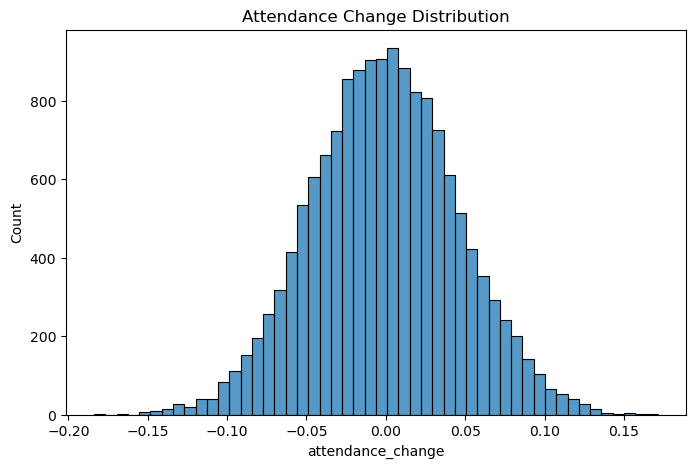

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    attendance_change["attendance_change"],
    bins=50
)

plt.title("Attendance Change Distribution")
plt.show()

In [87]:
train = train.merge(
    attendance_change,
    on="student_id",
    how="left"
)

test = test.merge(
    attendance_change,
    on="student_id",
    how="left"
)

In [88]:
train.groupby("dropout_risk")[
    "attendance_change"
].mean()

dropout_risk
0    0.001967
1   -0.002397
2   -0.007878
Name: attendance_change, dtype: float64

In [89]:
from scipy.stats import linregress

def calculate_slope(group):
    return linregress(
        group["week"],
        group["attendance_pct"]
    ).slope

attendance_slope = (
    attendance_weekly
    .groupby("student_id")
    .apply(calculate_slope)
    .reset_index(name="attendance_slope")
)

attendance_slope.head()

C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\428793915.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_slope)


,student_id,attendance_slope
0,STU00001,0.005898
1,STU00002,-0.014171
2,STU00003,-0.004762
3,STU00004,-0.000674
4,STU00005,-0.000576


In [90]:
train = train.merge(
    attendance_slope,
    on="student_id",
    how="left"
)

test = test.merge(
    attendance_slope,
    on="student_id",
    how="left"
)

In [91]:
train.groupby("dropout_risk")[
    "attendance_slope"
].mean()

dropout_risk
0    0.000541
1   -0.000649
2   -0.001791
Name: attendance_slope, dtype: float64

In [94]:
semester_attendance = (
    attendance.groupby(
        ["student_id", "semester"]
    )["attendance_pct"]
    .mean()
    .unstack()
    .reset_index()
)

semester_attendance.columns = [
    "student_id",
    "attendance_sem1",
    "attendance_sem2",
    "attendance_sem3"
]

In [95]:
semester_attendance.head()

,student_id,attendance_sem1,attendance_sem2,attendance_sem3
0,STU00001,0.821704,0.791467,0.806850
1,STU00002,0.959000,0.871404,0.909618
2,STU00003,0.742754,0.751625,0.733991
3,STU00004,0.800104,0.797804,0.742382
4,STU00005,0.765017,0.785500,0.797891


In [96]:
semester_attendance["attendance_sem_trend"] = (
    semester_attendance["attendance_sem3"]
    - semester_attendance["attendance_sem1"]
)

In [97]:
train = train.merge(
    semester_attendance,
    on="student_id",
    how="left"
)

test = test.merge(
    semester_attendance,
    on="student_id",
    how="left"
)

In [98]:
importance = model.get_feature_importance(prettified=True)

importance.head(30)

,Feature Id,Importances
0,screen_time_hours,6.936419
1,family_income,6.428104
2,commute_time_mins,6.222614
3,cgpa_std,6.082538
4,cgpa_sem2,5.642323
5,cgpa_trend,5.605464
6,cgpa_sem1,4.344751
7,attendance_mean_x,4.226621
8,cgpa_sem4,4.215761
9,cgpa_sem3,4.169614


In [99]:
print(train.columns.tolist())

['student_id', 'branch', 'gender', 'hostel_status', 'family_income', 'parent_education', 'scholarship', 'part_time_job', 'commute_time_mins', 'screen_time_hours', 'cgpa_sem1', 'cgpa_sem2', 'cgpa_sem3', 'cgpa_sem4', 'backlogs_sem1', 'backlogs_sem2', 'backlogs_sem3', 'dropout_risk', 'cgpa_mean', 'cgpa_std', 'cgpa_trend', 'backlog_total', 'backlog_mean', 'backlog_trend', 'attendance_mean', 'attendance_std', 'attendance_min', 'attendance_max', 'attendance_range', 'early_attendance_mean', 'late_attendance_mean', 'attendance_change', 'attendance_slope', 'attendance_sem1', 'attendance_sem2', 'attendance_sem3', 'attendance_sem_trend']


In [100]:
train.columns[train.columns.duplicated()]

Index([], dtype='object')

In [101]:
[col for col in train.columns if "_x" in col or "_y" in col]

[]

In [102]:
train_final = train_original.copy()
test_final = test_original.copy()

NameError: name 'train_original' is not defined

In [103]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

train_original = train.copy()
test_original = test.copy()

In [104]:
train_working = train_original.copy()
test_working = test_original.copy()

In [105]:
features = [
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4",
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3"
]

In [106]:
features = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education",
    "scholarship",
    "part_time_job",
    "commute_time_mins",
    "screen_time_hours",
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4",
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3"
]

In [107]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
import numpy as np

def run_cv(train_df, features, cat_features):

    X = train_df[features]
    y = train_df["dropout_risk"]

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = CatBoostClassifier(
            iterations=1000,
            depth=6,
            learning_rate=0.05,
            loss_function="MultiClass",
            random_seed=42,
            verbose=False
        )

        model.fit(
            X_train,
            y_train,
            cat_features=[
                col for col in cat_features
                if col in features
            ]
        )

        preds = model.predict(X_valid).flatten()

        score = f1_score(
            y_valid,
            preds,
            average="macro"
        )

        scores.append(score)

        print(f"Fold {fold+1}: {score:.4f}")

    print("\nMean CV Score:", np.mean(scores))

    return np.mean(scores)

In [108]:
cat_features = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education"
]

In [109]:
academic_features = [
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4",
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3"
]

score_academic = run_cv(
    train,
    academic_features,
    cat_features=[]
)

Fold 1: 0.4937
Fold 2: 0.4840
Fold 3: 0.4982
Fold 4: 0.4759
Fold 5: 0.4921

Mean CV Score: 0.4887851885259873


In [112]:
cat_cols = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education"
]

for col in cat_cols:
    train[col] = train[col].fillna("Missing").astype(str)

In [113]:
train[cat_cols].isnull().sum()

branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64

In [114]:
train["commute_time_mins"] = train["commute_time_mins"].fillna(
    train["commute_time_mins"].median()
)

In [115]:
score_demo = run_cv(
    train,
    demo_features,
    cat_features=cat_features
)

Fold 1: 0.5313
Fold 2: 0.5001
Fold 3: 0.5230
Fold 4: 0.4946
Fold 5: 0.5161

Mean CV Score: 0.5130350094442684


In [116]:
[col for col in train.columns if "attendance" in col]

[]

In [ ]:
attendance_features = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education",
    "scholarship",
    "part_time_job",
    "commute_time_mins",
    "screen_time_hours",
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4",
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3",
    "attendance_mean",
    "attendance_std",
    "attendance_min",
    "attendance_max",
    "attendance_range",1111
    "attendance_change"
]

In [131]:
attendance_cols = [col for col in train.columns if "attendance" in col]

print(attendance_cols)

['attendance_slope_x', 'attendance_sem1_x', 'attendance_sem2_x', 'attendance_sem3_x', 'attendance_sem_trend_x', 'attendance_slope_y', 'attendance_sem1_y', 'attendance_sem2_y', 'attendance_sem3_y', 'attendance_sem_trend_y']


In [132]:
attendance_features = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education",
    "scholarship",
    "part_time_job",
    "commute_time_mins",
    "screen_time_hours",
    "cgpa_sem1",
    "cgpa_sem2",
    "cgpa_sem3",
    "cgpa_sem4",
    "backlogs_sem1",
    "backlogs_sem2",
    "backlogs_sem3"
] + attendance_cols

In [133]:
score_attendance = run_cv(
    train,
    attendance_features,
    cat_features=cat_features
)

Fold 1: 0.5446
Fold 2: 0.4943
Fold 3: 0.5200
Fold 4: 0.5038
Fold 5: 0.5173

Mean CV Score: 0.5159940400866019


In [122]:
attendance_cols = [col for col in train.columns if "attendance" in col]

print("Attendance Columns:")
for col in attendance_cols:
    print(col)

Attendance Columns:


In [123]:
attendance_slope.head()

,student_id,attendance_slope
0,STU00001,0.005898
1,STU00002,-0.014171
2,STU00003,-0.004762
3,STU00004,-0.000674
4,STU00005,-0.000576


In [124]:
semester_attendance.head()

,student_id,attendance_sem1,attendance_sem2,attendance_sem3,attendance_sem_trend
0,STU00001,0.821704,0.791467,0.806850,-0.014854
1,STU00002,0.959000,0.871404,0.909618,-0.049382
2,STU00003,0.742754,0.751625,0.733991,-0.008763
3,STU00004,0.800104,0.797804,0.742382,-0.057722
4,STU00005,0.765017,0.785500,0.797891,0.032874


In [202]:
train = train.merge(
    attendance_slope,
    on="student_id",
    how="left"
)

train = train.merge(
    semester_attendance,
    on="student_id",
    how="left"
)

In [203]:
from scipy.stats import linregress

attendance_weekly = (
    attendance.groupby(
        ["student_id", "week"]
    )["attendance_pct"]
    .mean()
    .reset_index()
)

def calculate_slope(group):
    return linregress(
        group["week"],
        group["attendance_pct"]
    ).slope

attendance_slope = (
    attendance_weekly
    .groupby("student_id")
    .apply(calculate_slope)
    .reset_index(name="attendance_slope")
)

C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\1904811368.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_slope)


In [204]:
semester_attendance = (
    attendance.groupby(
        ["student_id", "semester"]
    )["attendance_pct"]
    .mean()
    .unstack()
    .reset_index()
)

semester_attendance.columns = [
    "student_id",
    "attendance_sem1",
    "attendance_sem2",
    "attendance_sem3"
]

semester_attendance["attendance_sem_trend"] = (
    semester_attendance["attendance_sem3"]
    - semester_attendance["attendance_sem1"]
)

In [205]:
train = train.merge(
    attendance_slope,
    on="student_id",
    how="left"
)

train = train.merge(
    semester_attendance,
    on="student_id",
    how="left"
)

In [206]:
[col for col in train.columns if "attendance" in col]

['attendance_mean',
 'attendance_std',
 'attendance_min',
 'attendance_max',
 'attendance_range',
 'attendance_slope_x',
 'attendance_sem1_x',
 'attendance_sem2_x',
 'attendance_sem3_x',
 'attendance_sem_trend_x',
 'attendance_slope_y',
 'attendance_sem1_y',
 'attendance_sem2_y',
 'attendance_sem3_y',
 'attendance_sem_trend_y',
 'attendance_slope',
 'attendance_sem1',
 'attendance_sem2',
 'attendance_sem3',
 'attendance_sem_trend']

In [207]:
notes.head()

,student_id,counsellor_note
0,STU00001,Student is performing well. Follow-up required.
1,STU00002,Needs to improve focus in class. Action plan d...
2,STU00003,"Struggling slightly with core subjects, advise..."
3,STU00004,Student expressed some stress regarding course...
4,STU00005,Multiple backlogs. Demotivated. Action plan di...


In [208]:
train = train.merge(
    notes,
    on="student_id",
    how="left"
)

test = test.merge(
    notes,
    on="student_id",
    how="left"
)

In [209]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=200,
    stop_words="english"
)

train_tfidf = tfidf.fit_transform(
    train["counsellor_note"]
)

test_tfidf = tfidf.transform(
    test["counsellor_note"]
)

KeyError: 'counsellor_note'

In [137]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=20,
    random_state=42
)

train_svd = svd.fit_transform(train_tfidf)
test_svd = svd.transform(test_tfidf)

In [138]:
import pandas as pd

svd_cols = [
    f"note_svd_{i}"
    for i in range(20)
]

train_svd_df = pd.DataFrame(
    train_svd,
    columns=svd_cols
)

test_svd_df = pd.DataFrame(
    test_svd,
    columns=svd_cols
)

In [139]:
train = pd.concat(
    [train.reset_index(drop=True),
     train_svd_df],
    axis=1
)

test = pd.concat(
    [test.reset_index(drop=True),
     test_svd_df],
    axis=1
)

In [140]:
nlp_features = attendance_features + svd_cols

In [141]:
score_nlp = run_cv(
    train,
    nlp_features,
    cat_features=cat_features
)

Fold 1: 0.7031
Fold 2: 0.6741
Fold 3: 0.7010
Fold 4: 0.6936
Fold 5: 0.6989

Mean CV Score: 0.6941181811330309


In [142]:
from lightgbm import LGBMClassifier

In [143]:
from xgboost import XGBClassifier

In [147]:
# 1. Reload fresh copies of the data to clear the dirty merges
# 1. Reload fresh copies using correct paths (going up one folder using ../)
train = pd.read_csv("../Data/raw/train.csv")
test = pd.read_csv("../Data/raw/test.csv")

In [148]:
attendance = pd.read_csv("../Data/raw/Attendance_series.csv")

In [149]:
train = train.merge(attendance_stats, on="student_id", how="left")
test = test.merge(attendance_stats, on="student_id", how="left")
# 3. Now define your features list (it will no longer contain _x and _y columns!)
features = [col for col in train.columns if col not in ["dropout_risk", "student_id"]]
X = train[features]
y = train["dropout_risk"]
X_test = test[features] 

In [150]:
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from catboost import CatBoostClassifier

In [151]:
oof_cat = np.zeros((len(train), 3))

test_cat = np.zeros((len(test), 3))

In [152]:
print(oof_cat.shape)
print(test_cat.shape)

(12000, 3)
(3000, 3)


In [153]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [154]:
for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X, y)
):

    print(f"\nFold {fold+1}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [155]:
cat_features_fold = [
    col for col in cat_features
    if col in features
]

X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[valid_idx]

model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features_fold
)

CatBoostError: Invalid type for cat_feature[non-default value idx=15,feature_idx=4]=nan : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [156]:
# List of categorical features
cat_features_fold = ["branch", "gender", "hostel_status", "family_income", "parent_education"]

# Fill NaNs and convert to string on the master X DataFrame
for col in cat_features_fold:
    X[col] = X[col].fillna("Missing").astype(str)

# (Optional check to confirm it worked—should print all 0s)
print(X[cat_features_fold].isna().sum())

branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64


C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\826968617.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna("Missing").astype(str)
C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\826968617.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna("Missing").astype(str)
C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\826968617.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [157]:
X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[valid_idx]

model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features_fold
)

CatBoostClassifier(depth=6, iterations=1000, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=False)

In [158]:
valid_probs = model.predict_proba(X_valid)

oof_cat[valid_idx] = valid_probs

In [159]:
print(valid_probs.shape)

(2400, 3)


In [161]:
# Clean the X_test DataFrame
for col in cat_features_fold:
    X_test[col] = X_test[col].fillna("Missing").astype(str)

# (Optional check—should print all 0s)
print(X_test[cat_features_fold].isna().sum())
test_probs = model.predict_proba(X_test)

test_cat += test_probs / skf.n_splits

branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64


C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\2490929742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].fillna("Missing").astype(str)
C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\2490929742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].fillna("Missing").astype(str)
C:\Users\hawka\AppData\Local\Temp\ipykernel_26964\2490929742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [162]:
valid_preds = np.argmax(
    valid_probs,
    axis=1
)

fold_score = f1_score(
    y_valid,
    valid_preds,
    average="macro"
)

print(
    f"Fold {fold+1} F1: {fold_score:.4f}"
)

Fold 5 F1: 0.5184


In [163]:
oof_preds = np.argmax(
    oof_cat,
    axis=1
)

cv_score = f1_score(
    y,
    oof_preds,
    average="macro"
)

print("\nFinal OOF CV Score:")
print(cv_score)


Final OOF CV Score:
0.3267283259668168


In [164]:
print(oof_cat.shape)
print(test_cat.shape)

(12000, 3)
(3000, 3)


In [165]:
print(X.shape)
print(len(features))
print(features[:10])

(12000, 21)
21
['branch', 'gender', 'hostel_status', 'family_income', 'parent_education', 'scholarship', 'part_time_job', 'commute_time_mins', 'screen_time_hours', 'cgpa_sem1']


In [166]:
features = nlp_features

In [167]:
features = demo_features


In [168]:
print(oof_cat.shape)
print(np.unique(np.argmax(oof_cat, axis=1), return_counts=True))

(12000, 3)
(array([0, 1, 2]), array([11511,   210,   279]))


In [172]:
len(nlp_features)

46

In [173]:
[col for col in nlp_features if "note_svd" in col][:5]

['note_svd_0', 'note_svd_1', 'note_svd_2', 'note_svd_3', 'note_svd_4']

In [192]:
print(len(features))

print(features[-10:])

46
['note_svd_10', 'note_svd_11', 'note_svd_12', 'note_svd_13', 'note_svd_14', 'note_svd_15', 'note_svd_16', 'note_svd_17', 'note_svd_18', 'note_svd_19']


In [193]:
print(len(nlp_features))
print([c for c in nlp_features if "note_svd" in c][:5])

46
['note_svd_0', 'note_svd_1', 'note_svd_2', 'note_svd_3', 'note_svd_4']


In [194]:
features = nlp_features

X = train[features]
y = train["dropout_risk"]

X_test = test[features]

KeyError: "['attendance_slope_x', 'attendance_sem1_x', 'attendance_sem2_x', 'attendance_sem3_x', 'attendance_sem_trend_x', 'attendance_slope_y', 'attendance_sem1_y', 'attendance_sem2_y', 'attendance_sem3_y', 'attendance_sem_trend_y', 'note_svd_0', 'note_svd_1', 'note_svd_2', 'note_svd_3', 'note_svd_4', 'note_svd_5', 'note_svd_6', 'note_svd_7', 'note_svd_8', 'note_svd_9', 'note_svd_10', 'note_svd_11', 'note_svd_12', 'note_svd_13', 'note_svd_14', 'note_svd_15', 'note_svd_16', 'note_svd_17', 'note_svd_18', 'note_svd_19'] not in index"

In [195]:
print(len(features))
print(features[-10:])

46
['note_svd_10', 'note_svd_11', 'note_svd_12', 'note_svd_13', 'note_svd_14', 'note_svd_15', 'note_svd_16', 'note_svd_17', 'note_svd_18', 'note_svd_19']


In [196]:
oof_cat = np.zeros((len(train), 3))
test_cat = np.zeros((len(test), 3))

In [197]:
oof_preds = np.argmax(oof_cat, axis=1)

cv_score = f1_score(
    y,
    oof_preds,
    average="macro"
)

print(cv_score)

0.25


In [198]:
oof_cat = np.zeros((len(train), 3))
test_cat = np.zeros((len(test), 3))

In [199]:
oof_preds = np.argmax(oof_cat, axis=1)

In [200]:
print(np.unique(oof_preds, return_counts=True))

(array([0]), array([12000]))


In [210]:
print(train.shape)

print([c for c in train.columns if "note_svd" in c][:5])

(12000, 40)
[]


In [211]:
'train_svd_df' in globals()

True

In [212]:
'test_svd_df' in globals()

True

In [213]:
try:
    print(train_svd_df.shape)
except:
    print("train_svd_df missing")

(12000, 20)


In [214]:
train = pd.concat(
    [train.reset_index(drop=True),
     train_svd_df.reset_index(drop=True)],
    axis=1
)

test = pd.concat(
    [test.reset_index(drop=True),
     test_svd_df.reset_index(drop=True)],
    axis=1
)

In [215]:
print(len([c for c in train.columns if "note_svd" in c]))

20


In [216]:
clean_nlp_features = [
    col for col in nlp_features
    if col in train.columns
]

In [217]:
print(len(clean_nlp_features))

missing = [
    col for col in nlp_features
    if col not in train.columns
]

print("Missing:", missing)

46
Missing: []


In [219]:
features = clean_nlp_features

X = train[features]
y = train["dropout_risk"]

missing_in_test = [
    col for col in features
    if col not in test.columns
]

print(missing_in_test)
print(len(missing_in_test))

['attendance_slope_x', 'attendance_sem1_x', 'attendance_sem2_x', 'attendance_sem3_x', 'attendance_sem_trend_x', 'attendance_slope_y', 'attendance_sem1_y', 'attendance_sem2_y', 'attendance_sem3_y', 'attendance_sem_trend_y']
10


In [220]:
features = [
    col
    for col in train.columns
    if (
        col in test.columns
        and col != "student_id"
        and col != "dropout_risk"
        and col != "counsellor_note"
    )
]

In [221]:
print(len(features))

43


In [222]:
missing_in_test = [
    col for col in features
    if col not in test.columns
]

print(missing_in_test)

[]


In [223]:
X = train[features]
y = train["dropout_risk"]

X_test = test[features]

In [224]:
oof_cat = np.zeros((len(train), 3))
test_cat = np.zeros((len(test), 3))

In [225]:
cat_features_fold = [
    col for col in cat_features
    if col in features
]

print(cat_features_fold)

['branch', 'gender', 'hostel_status', 'family_income', 'parent_education']


In [226]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [228]:
for col in cat_features_fold:
    print(col, X[col].isna().sum())

branch 0
gender 0
hostel_status 0
family_income 0
parent_education 238


In [229]:
for col in cat_features_fold:
    train[col] = train[col].fillna("Missing").astype(str)
    test[col] = test[col].fillna("Missing").astype(str)

In [230]:
train["commute_time_mins"] = train["commute_time_mins"].fillna(
    train["commute_time_mins"].median()
)

test["commute_time_mins"] = test["commute_time_mins"].fillna(
    train["commute_time_mins"].median()
)

In [231]:
print(train[cat_features_fold].isnull().sum())
print(test[cat_features_fold].isnull().sum())

branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64
branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64


In [232]:
X = train[features]
y = train["dropout_risk"]

X_test = test[features]

In [233]:
oof_cat = np.zeros((len(train), 3))
test_cat = np.zeros((len(test), 3))

In [234]:
print(X[cat_features_fold].isna().sum())

branch              0
gender              0
hostel_status       0
family_income       0
parent_education    0
dtype: int64


In [236]:
print("counsellor_note" in features)

False


In [237]:
print(X.dtypes[X.dtypes == "object"])

branch               object
gender               object
hostel_status        object
family_income        object
parent_education     object
counsellor_note_x    object
counsellor_note_y    object
dtype: object


In [238]:
for col in X.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(X[col].head())


branch
0      AIML
1        CE
2      AIML
3    CSE-DS
4       CSE
Name: branch, dtype: object

gender
0    M
1    M
2    F
3    M
4    M
Name: gender, dtype: object

hostel_status
0         Hostel
1         Hostel
2    Day Scholar
3         Hostel
4    Day Scholar
Name: hostel_status, dtype: object

family_income
0      High
1    Medium
2       Low
3    Medium
4    Medium
Name: family_income, dtype: object

parent_education
0      Bachelors
1        Masters
2    High School
3    High School
4            PhD
Name: parent_education, dtype: object

counsellor_note_x
0    Discussed minor career goals, doing fine. Acti...
1    Student expressed some stress regarding course...
2      Student is performing well. Follow-up required.
3        No major issues reported. Follow-up required.
4       No major issues reported. Situation monitored.
Name: counsellor_note_x, dtype: object

counsellor_note_y
0    Discussed minor career goals, doing fine. Acti...
1    Student expressed some stress regar

In [239]:
print(X.select_dtypes(include="object").columns.tolist())

['branch', 'gender', 'hostel_status', 'family_income', 'parent_education', 'counsellor_note_x', 'counsellor_note_y']


In [240]:
for col in X.columns:
    sample = X[col].astype(str).head(50)

    if sample.str.contains(
        "Discussed minor career goals",
        case=False,
        na=False
    ).any():
        print("FOUND IN:", col)

FOUND IN: counsellor_note_x
FOUND IN: counsellor_note_y


In [241]:
print(X.select_dtypes(include="object").columns.tolist())

['branch', 'gender', 'hostel_status', 'family_income', 'parent_education', 'counsellor_note_x', 'counsellor_note_y']


In [242]:
features = [
    col for col in features
    if col not in [
        "counsellor_note",
        "counsellor_note_x",
        "counsellor_note_y"
    ]
]

In [243]:
X = train[features]
y = train["dropout_risk"]

X_test = test[features]

In [244]:
print(X.select_dtypes(include="object").columns.tolist())

['branch', 'gender', 'hostel_status', 'family_income', 'parent_education']


In [245]:
oof_cat = np.zeros((len(train), 3))
test_cat = np.zeros((len(test), 3))

In [246]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features_fold
    )

    valid_probs = model.predict_proba(X_valid)
    oof_cat[valid_idx] = valid_probs

    test_probs = model.predict_proba(X_test)
    test_cat += test_probs / 5

    valid_preds = np.argmax(valid_probs, axis=1)

    fold_score = f1_score(
        y_valid,
        valid_preds,
        average="macro"
    )

    print(f"Fold F1: {fold_score:.4f}")


Fold 1
Fold F1: 0.7034

Fold 2
Fold F1: 0.6819

Fold 3
Fold F1: 0.6992

Fold 4
Fold F1: 0.6952

Fold 5
Fold F1: 0.7153


In [ ]:
oof_preds = np.argmax(oof_cat, axis=1)
cv_score = f1_score(
    y,oof_preds,average="macro"
)
print("\nFinal OOF CV Score:")
print(cv_score)


Final OOF CV Score:
0.6990661103114015


In [ ]:
from collections import Counter
test_preds = np.argmax(test_cat, axis=1)
print(Counter(test_preds))

Counter({np.int64(0): 1890, np.int64(1): 697, np.int64(2): 413})


In [249]:
attendance_cols = [c for c in train.columns if "attendance" in c]

for col in attendance_cols:
    print(col)

attendance_mean
attendance_std
attendance_min
attendance_max
attendance_range
attendance_slope_x
attendance_sem1_x
attendance_sem2_x
attendance_sem3_x
attendance_sem_trend_x
attendance_slope_y
attendance_sem1_y
attendance_sem2_y
attendance_sem3_y
attendance_sem_trend_y
attendance_slope
attendance_sem1
attendance_sem2
attendance_sem3
attendance_sem_trend


In [250]:
attendance_compare = [
    ("attendance_slope_x", "attendance_slope"),
    ("attendance_sem1_x", "attendance_sem1"),
    ("attendance_sem2_x", "attendance_sem2"),
    ("attendance_sem3_x", "attendance_sem3"),
    ("attendance_sem_trend_x", "attendance_sem_trend"),
]

for a, b in attendance_compare:
    print(a, b)
    print((train[a] == train[b]).all())
    print()

attendance_slope_x attendance_slope
True

attendance_sem1_x attendance_sem1
True

attendance_sem2_x attendance_sem2
True

attendance_sem3_x attendance_sem3
True

attendance_sem_trend_x attendance_sem_trend
True



In [251]:
attendance_compare = [
    ("attendance_slope_y", "attendance_slope"),
    ("attendance_sem1_y", "attendance_sem1"),
    ("attendance_sem2_y", "attendance_sem2"),
    ("attendance_sem3_y", "attendance_sem3"),
    ("attendance_sem_trend_y", "attendance_sem_trend"),
]

for a, b in attendance_compare:
    print(a, b)
    print((train[a] == train[b]).all())
    print()

attendance_slope_y attendance_slope
True

attendance_sem1_y attendance_sem1
True

attendance_sem2_y attendance_sem2
True

attendance_sem3_y attendance_sem3
True

attendance_sem_trend_y attendance_sem_trend
True



In [253]:
duplicate_cols = [
    "attendance_slope_x",
    "attendance_sem1_x",
    "attendance_sem2_x",
    "attendance_sem3_x",
    "attendance_sem_trend_x",
    "attendance_slope_y",
    "attendance_sem1_y",
    "attendance_sem2_y",
    "attendance_sem3_y",
    "attendance_sem_trend_y",
]

train.drop(
    columns=[c for c in duplicate_cols if c in train.columns],
    inplace=True
)

test.drop(
    columns=[c for c in duplicate_cols if c in test.columns],
    inplace=True
)

In [254]:
[c for c in train.columns if "attendance" in c]

['attendance_mean',
 'attendance_std',
 'attendance_min',
 'attendance_max',
 'attendance_range',
 'attendance_slope',
 'attendance_sem1',
 'attendance_sem2',
 'attendance_sem3',
 'attendance_sem_trend']

In [255]:
print(train.shape)
print(test.shape)

(12000, 50)
(3000, 44)


In [256]:
print(len(train.columns))
print(len(test.columns))

50
44


In [257]:
%pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.


In [258]:
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import numpy as np

In [259]:
features = [
    col
    for col in train.columns
    if col not in [
        "student_id",
        "dropout_risk"
    ]
]

In [260]:
cat_cols = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education"
]

In [261]:
for col in cat_cols:

    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

    mapping = {
        k: i
        for i, k in enumerate(
            train[col].cat.categories
        )
    }

    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)

In [263]:
missing_in_test = [
    col for col in features
    if col not in test.columns
]

print(missing_in_test)
print("\nCount:", len(missing_in_test))

['attendance_slope', 'attendance_sem1', 'attendance_sem2', 'attendance_sem3', 'attendance_sem_trend']

Count: 5


In [264]:
missing_in_train = [
    col for col in test.columns
    if col not in train.columns
]

print(missing_in_train)

[]


In [265]:
common_features = [
    col for col in features
    if col in train.columns
    and col in test.columns
]

In [267]:
print(len(common_features))

43


In [268]:
X = train[common_features]

y = train["dropout_risk"]

X_test = test[common_features]

In [269]:
print(
    set(train.columns) -
    set(test.columns)
)

{'attendance_sem_trend', 'attendance_slope', 'attendance_sem2', 'dropout_risk', 'attendance_sem3', 'attendance_sem1'}


In [270]:
print(train.shape)
print(test.shape)

(12000, 50)
(3000, 44)


In [271]:
[c for c in train.columns if "attendance_sem" in c]

['attendance_sem1',
 'attendance_sem2',
 'attendance_sem3',
 'attendance_sem_trend']

In [272]:
[c for c in test.columns if "attendance_sem" in c]

[]

In [273]:
semester_attendance = (
    attendance
    .groupby(["student_id","semester"])
    ["attendance_pct"]
    .mean()
)

In [274]:
[c for c in train.columns if "attendance" in c]

['attendance_mean',
 'attendance_std',
 'attendance_min',
 'attendance_max',
 'attendance_range',
 'attendance_slope',
 'attendance_sem1',
 'attendance_sem2',
 'attendance_sem3',
 'attendance_sem_trend']

In [275]:
attendance_feature_cols = [
    "attendance_slope",
    "attendance_sem1",
    "attendance_sem2",
    "attendance_sem3",
    "attendance_sem_trend"
]

for col in attendance_feature_cols:
    print(col, col in train.columns, col in test.columns)

attendance_slope True False
attendance_sem1 True False
attendance_sem2 True False
attendance_sem3 True False
attendance_sem_trend True False


In [276]:
semester_attendance = (
    attendance
    .groupby(["student_id","semester"])["attendance_pct"]
    .mean()
    .reset_index()
)

semester_pivot = semester_attendance.pivot(
    index="student_id",
    columns="semester",
    values="attendance_pct"
)

In [277]:
for col in train.columns:
    if "attendance_sem" in col or "attendance_slope" in col:
        print(col)

attendance_slope
attendance_sem1
attendance_sem2
attendance_sem3
attendance_sem_trend


In [280]:
semester_attendance = (
    attendance
    .groupby(["student_id","semester"])["attendance_pct"]
    .mean()
    .reset_index()
)

semester_pivot = semester_attendance.pivot(
    index="student_id",
    columns="semester",
    values="attendance_pct"
)

In [281]:
for col in train.columns:
    if "attendance_sem" in col or "attendance_slope" in col:
        print(col)

attendance_slope
attendance_sem1
attendance_sem2
attendance_sem3
attendance_sem_trend


In [282]:
print(attendance_sem_features.shape)
print(attendance_sem_features.head())

NameError: name 'attendance_sem_features' is not defined

In [283]:
semester_attendance
semester_pivot

semester,1,2,3
student_id,,,
STU00001,0.821704,0.791467,0.806850
STU00002,0.959000,0.871404,0.909618
STU00003,0.742754,0.751625,0.733991
STU00004,0.800104,0.797804,0.742382
STU00005,0.765017,0.785500,0.797891
...,...,...,...
STU14996,0.638567,0.648038,0.643695
STU14997,0.760933,0.767554,0.701829
STU14998,0.652692,0.682250,0.695786


In [284]:
print(semester_pivot.head())
print(semester_pivot.columns)
print(semester_pivot.shape)

semester           1         2         3
student_id                              
STU00001    0.821704  0.791467  0.806850
STU00002    0.959000  0.871404  0.909618
STU00003    0.742754  0.751625  0.733991
STU00004    0.800104  0.797804  0.742382
STU00005    0.765017  0.785500  0.797891
Index([1, 2, 3], dtype='int64', name='semester')
(15000, 3)


In [285]:
semester_pivot = semester_pivot.reset_index()

semester_pivot["attendance_sem1"] = semester_pivot[1]
semester_pivot["attendance_sem2"] = semester_pivot[2]
semester_pivot["attendance_sem3"] = semester_pivot[3]

semester_pivot["attendance_slope"] = (
    semester_pivot["attendance_sem3"]
    - semester_pivot["attendance_sem1"]
)

semester_pivot["attendance_sem_trend"] = (
    semester_pivot["attendance_sem3"]
    - semester_pivot["attendance_sem2"]
)

In [286]:
semester_features = semester_pivot[
    [
        "student_id",
        "attendance_sem1",
        "attendance_sem2",
        "attendance_sem3",
        "attendance_slope",
        "attendance_sem_trend"
    ]
]

print(semester_features.head())
print(semester_features.shape)

semester student_id  attendance_sem1  attendance_sem2  attendance_sem3  \
0          STU00001         0.821704         0.791467         0.806850   
1          STU00002         0.959000         0.871404         0.909618   
2          STU00003         0.742754         0.751625         0.733991   
3          STU00004         0.800104         0.797804         0.742382   
4          STU00005         0.765017         0.785500         0.797891   

semester  attendance_slope  attendance_sem_trend  
0                -0.014854              0.015383  
1                -0.049382              0.038214  
2                -0.008763             -0.017634  
3                -0.057722             -0.055422  
4                 0.032874              0.012391  
(15000, 6)


In [287]:
test = test.merge(
    semester_features,
    on="student_id",
    how="left"
)

In [288]:
test = test.merge(
    semester_features,
    on="student_id",
    how="left"
)

In [289]:
for col in [
    "attendance_slope",
    "attendance_sem1",
    "attendance_sem2",
    "attendance_sem3",
    "attendance_sem_trend"
]:
    print(col, col in test.columns)

attendance_slope False
attendance_sem1 False
attendance_sem2 False
attendance_sem3 False
attendance_sem_trend False


In [290]:
missing_in_test = [
    col for col in train.columns
    if col not in test.columns
]

print(missing_in_test)

['dropout_risk', 'attendance_slope', 'attendance_sem1', 'attendance_sem2', 'attendance_sem3', 'attendance_sem_trend']


In [291]:
print(semester_pivot.head())

print("\nColumns:")
print(semester_pivot.columns.tolist())

semester student_id         1         2         3  attendance_sem1  \
0          STU00001  0.821704  0.791467  0.806850         0.821704   
1          STU00002  0.959000  0.871404  0.909618         0.959000   
2          STU00003  0.742754  0.751625  0.733991         0.742754   
3          STU00004  0.800104  0.797804  0.742382         0.800104   
4          STU00005  0.765017  0.785500  0.797891         0.765017   

semester  attendance_sem2  attendance_sem3  attendance_slope  \
0                0.791467         0.806850         -0.014854   
1                0.871404         0.909618         -0.049382   
2                0.751625         0.733991         -0.008763   
3                0.797804         0.742382         -0.057722   
4                0.785500         0.797891          0.032874   

semester  attendance_sem_trend  
0                     0.015383  
1                     0.038214  
2                    -0.017634  
3                    -0.055422  
4                     0.01239

In [292]:
print(semester_pivot.shape)

(15000, 9)


In [293]:
semester_features = semester_pivot[
    [
        "student_id",
        "attendance_sem1",
        "attendance_sem2",
        "attendance_sem3",
        "attendance_slope",
        "attendance_sem_trend"
    ]
].copy()

print(semester_features.shape)
semester_features.head()

(15000, 6)


semester,student_id,attendance_sem1,attendance_sem2,attendance_sem3,attendance_slope,attendance_sem_trend
0,STU00001,0.821704,0.791467,0.806850,-0.014854,0.015383
1,STU00002,0.959000,0.871404,0.909618,-0.049382,0.038214
2,STU00003,0.742754,0.751625,0.733991,-0.008763,-0.017634
3,STU00004,0.800104,0.797804,0.742382,-0.057722,-0.055422
4,STU00005,0.765017,0.785500,0.797891,0.032874,0.012391


In [294]:
test = test.merge(
    semester_features,
    on="student_id",
    how="left"
)

In [295]:
for col in [
    "attendance_slope",
    "attendance_sem1",
    "attendance_sem2",
    "attendance_sem3",
    "attendance_sem_trend"
]:
    print(col, col in test.columns)

attendance_slope True
attendance_sem1 True
attendance_sem2 True
attendance_sem3 True
attendance_sem_trend True


In [296]:
missing_in_test = [
    col
    for col in train.columns
    if col not in test.columns
]

print(missing_in_test)

['dropout_risk']


In [297]:
features = [
    col
    for col in train.columns
    if col not in [
        "student_id",
        "dropout_risk"
    ]
]

In [298]:
print(len(features))

print(
    len(
        [c for c in features if c in test.columns]
    )
)

48
48


In [299]:
print(len(features))

print(
    len(
        [c for c in features if c in test.columns]
    )
)

48
48


In [300]:
missing_in_test = [
    col for col in features
    if col not in test.columns
]

print("Missing:", missing_in_test)

Missing: []


In [302]:
cat_cols = [
    "branch",
    "gender",
    "hostel_status",
    "family_income",
    "parent_education"
]

for col in cat_cols:

    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

    train[col] = train[col].replace("nan", "Missing")
    test[col] = test[col].replace("nan", "Missing")

In [303]:
for col in cat_cols:

    all_values = sorted(
        set(train[col].unique()) |
        set(test[col].unique())
    )

    mapping = {
        val: idx
        for idx, val in enumerate(all_values)
    }

    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)

In [304]:
for col in cat_cols:
    print(
        col,
        train[col].isna().sum(),
        test[col].isna().sum()
    )

branch 0 0
gender 0 0
hostel_status 0 0
family_income 0 0
parent_education 0 0


In [305]:
X = train[features]
y = train["dropout_risk"]

X_test = test[features]

In [306]:
print(X.shape)
print(X_test.shape)

(12000, 48)
(3000, 48)


In [308]:
bad_cols = [
    "counsellor_note_x",
    "counsellor_note_y"
]

features = [
    col
    for col in features
    if col not in bad_cols
]

X = train[features]
X_test = test[features]

In [309]:
print(
    X.select_dtypes(include="object").columns.tolist()
)

[]


In [310]:
X.dtypes.value_counts()

float64    36
int64      10
Name: count, dtype: int64

In [311]:
print(X.shape)
print(X_test.shape)

(12000, 46)
(3000, 46)


In [312]:
X.select_dtypes(include="object").columns.tolist()

[]

In [313]:
X.shape
X_test.shape

(3000, 46)

In [314]:
print(
    X.select_dtypes(include="object").columns.tolist()
)

[]


In [315]:
oof_lgb = np.zeros((len(train), 3))
test_lgb = np.zeros((len(test), 3))

In [316]:
oof_preds = np.argmax(
    oof_lgb,
    axis=1
)

print(
    f1_score(
        y,
        oof_preds,
        average="macro"
    )
)

0.25


In [317]:
oof_xgb = np.zeros((len(train), 3))
test_xgb = np.zeros((len(test), 3))

In [318]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

In [319]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier

oof_lgb = np.zeros((len(train), 3))
test_lgb = np.zeros((len(test), 3))

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train
    )

    valid_probs = model.predict_proba(X_valid)

    oof_lgb[valid_idx] = valid_probs

    test_lgb += (
        model.predict_proba(X_test) / 5
    )

    fold_preds = np.argmax(
        valid_probs,
        axis=1
    )

    fold_score = f1_score(
        y_valid,
        fold_preds,
        average="macro"
    )

    print(
        f"Fold F1: {fold_score:.4f}"
    )


Fold 1
Fold F1: 0.6956

Fold 2
Fold F1: 0.6827

Fold 3
Fold F1: 0.6797

Fold 4
Fold F1: 0.6813

Fold 5
Fold F1: 0.7039


In [320]:
oof_preds = np.argmax(
    oof_lgb,
    axis=1
)

lgb_score = f1_score(
    y,
    oof_preds,
    average="macro"
)

print("\nLightGBM OOF Score:")
print(lgb_score)


LightGBM OOF Score:
0.6886670865885035


In [321]:
from xgboost import XGBClassifier

oof_xgb = np.zeros((len(train), 3))
test_xgb = np.zeros((len(test), 3))

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=1500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist"
    )

    model.fit(
        X_train,
        y_train
    )

    valid_probs = model.predict_proba(
        X_valid
    )

    oof_xgb[valid_idx] = valid_probs

    test_xgb += (
        model.predict_proba(X_test) / 5
    )

    fold_preds = np.argmax(
        valid_probs,
        axis=1
    )

    fold_score = f1_score(
        y_valid,
        fold_preds,
        average="macro"
    )

    print(
        f"Fold F1: {fold_score:.4f}"
    )


Fold 1
Fold F1: 0.6948

Fold 2
Fold F1: 0.6880

Fold 3
Fold F1: 0.6919

Fold 4
Fold F1: 0.6842

Fold 5
Fold F1: 0.7043


In [322]:
oof_preds = np.argmax(
    oof_xgb,
    axis=1
)

xgb_score = f1_score(
    y,
    oof_preds,
    average="macro"
)

print("\nXGBoost OOF Score:")
print(xgb_score)


XGBoost OOF Score:
0.692702454500198


In [ ]:
ensemble_probs = (0.70 * oof_cat +0.15 * oof_lgb +0.15 * oof_xgb)
ensemble_preds = np.argmax(ensemble_probs,axis=1)
ensemble_score = f1_score(y,ensemble_preds,average="macro")
print("\nEnsemble OOF Score:")
print(ensemble_score)


Ensemble OOF Score:
0.7016673802222887


In [ ]:
ensemble_probs = (0.60 * oof_cat +0.20 * oof_lgb +0.20 * oof_xgb)
ensemble_preds = np.argmax(ensemble_probs,axis=1)
ensemble_score = f1_score(y,ensemble_preds,average="macro")
print(ensemble_score)

0.7006511067275653


In [325]:
ensemble_probs = (0.50 * oof_cat +0.25 * oof_lgb +0.25 * oof_xgb)
ensemble_preds = np.argmax(ensemble_probs,axis=1)
ensemble_score = f1_score(y,ensemble_preds,average="macro")
print(ensemble_score)

0.6985462979294822


In [326]:
ensemble_probs = (0.75 * oof_cat +0.25 * oof_xgb)
ensemble_preds = np.argmax(ensemble_probs,axis=1)
ensemble_score = f1_score(y,ensemble_preds,average="macro")
print(ensemble_score)

0.6993927225773939


In [327]:
ensemble_probs = (
    0.75 * oof_cat +
    0.25 * oof_lgb
)

ensemble_preds = np.argmax(
    ensemble_probs,
    axis=1
)

ensemble_score = f1_score(
    y,
    ensemble_preds,
    average="macro"
)

print(ensemble_score)

0.700831497006682


In [328]:
stack_train = np.hstack([
    oof_cat,
    oof_lgb,
    oof_xgb
])

stack_test = np.hstack([
    test_cat,
    test_lgb,
    test_xgb
])

print(stack_train.shape)
print(stack_test.shape)

(12000, 9)
(3000, 9)


In [329]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    random_state=42
)

meta_model.fit(
    stack_train,
    y
)

stack_preds = meta_model.predict(
    stack_train
)

stack_score = f1_score(
    y,
    stack_preds,
    average="macro"
)

print(stack_score)

0.6975142197207433


c:\Users\hawka\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [330]:
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=10,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=200
)


In [331]:
oof_cat_v2 = np.zeros((len(train), 3))
test_cat_v2 = np.zeros((len(test), 3))

In [332]:
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=10,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=False
)

In [334]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

CatBoostClassifier(depth=10, eval_metric='TotalF1', iterations=3000, learning_rate=0.02, loss_function='MultiClass', random_seed=42, verbose=False)

In [335]:
valid_probs = model.predict_proba(X_valid)

oof_cat_v2[valid_idx] = valid_probs

test_cat_v2 += (
    model.predict_proba(X_test) / 5
)

In [336]:
preds = np.argmax(
    oof_cat_v2,
    axis=1
)

score = f1_score(
    y,
    preds,
    average="macro"
)

print(score)

0.3905499480333983


In [337]:
print(oof_cat_v2.shape)

print(
    np.unique(
        np.argmax(oof_cat_v2, axis=1),
        return_counts=True
    )
)

(12000, 3)
(array([0, 1, 2]), array([11158,   504,   338]))


In [338]:
print(
    np.sum(oof_cat_v2)
)

2400.0


In [339]:
print(
    np.min(oof_cat_v2),
    np.max(oof_cat_v2)
)

0.0 0.9992096974244278


In [340]:
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=[1.0, 2.4, 4.0],
    random_seed=42,
    verbose=False
)

In [341]:
oof_cat_weighted = np.zeros((len(train), 3))
test_cat_weighted = np.zeros((len(test), 3))

In [342]:
preds = np.argmax(
    oof_cat_weighted,
    axis=1
)

weighted_score = f1_score(
    y,
    preds,
    average="macro"
)

print(weighted_score)

0.25


In [343]:
print(oof_cat_weighted.shape)

print(
    np.sum(oof_cat_weighted)
)

print(
    np.min(oof_cat_weighted),
    np.max(oof_cat_weighted)
)

print(
    np.unique(
        np.argmax(oof_cat_weighted, axis=1),
        return_counts=True
    )
)

(12000, 3)
0.0
0.0 0.0
(array([0]), array([12000]))


In [344]:
ensemble_probs = (
    0.70 * oof_cat +
    0.15 * oof_lgb +
    0.15 * oof_xgb
)

In [345]:
baseline_preds = np.argmax(
    ensemble_probs,
    axis=1
)

print(
    f1_score(
        y,
        baseline_preds,
        average="macro"
    )
)

0.7016673802222887


In [346]:
best_score = 0
best_t1 = 1
best_t2 = 1

for t1 in np.arange(0.8, 1.31, 0.05):
    for t2 in np.arange(0.8, 1.31, 0.05):

        probs = ensemble_probs.copy()

        probs[:, 1] *= t1
        probs[:, 2] *= t2

        preds = np.argmax(
            probs,
            axis=1
        )

        score = f1_score(
            y,
            preds,
            average="macro"
        )

        if score > best_score:
            best_score = score
            best_t1 = t1
            best_t2 = t2

print("Best Score:", best_score)
print("Class1 Weight:", best_t1)
print("Class2 Weight:", best_t2)

Best Score: 0.7071606009238599
Class1 Weight: 1.3000000000000005
Class2 Weight: 1.3000000000000005


In [347]:
ensemble_probs = (
    0.70 * oof_cat +
    0.15 * oof_lgb +
    0.15 * oof_xgb
)

ensemble_probs[:,1] *= 1.30
ensemble_probs[:,2] *= 1.30

preds = np.argmax(
    ensemble_probs,
    axis=1
)

In [348]:
final_test_probs = (
    0.70 * test_cat +
    0.15 * test_lgb +
    0.15 * test_xgb
)

In [349]:
final_test_probs[:,1] *= 1.30
final_test_probs[:,2] *= 1.30

In [350]:
final_preds = np.argmax(
    final_test_probs,
    axis=1
)

print(np.unique(
    final_preds,
    return_counts=True
))

(array([0, 1, 2]), array([1799,  753,  448]))


In [351]:
submission = pd.DataFrame({
    "student_id": test["student_id"],
    "dropout_risk": final_preds
})

submission.head()

,student_id,dropout_risk
0,STU03679,0
1,STU11070,0
2,STU13561,1
3,STU00061,1
4,STU02416,2


In [352]:
submission.to_csv(
    "submission_v1.csv",
    index=False
)

print(submission.shape)

(3000, 2)


In [353]:
submission["dropout_risk"].value_counts(normalize=True)

dropout_risk
0    0.599667
1    0.251000
2    0.149333
Name: proportion, dtype: float64